# BERTopic - Vibecoding Tweet Topic Modeling

Notebook ini menjalankan BERTopic pada dataset tweet vibecoding yang sama dengan FASTopic
(`preprocessed_new_vibe_coding_tweets.csv`) supaya hasilnya bisa dibandingkan apple-to-apple.

**Pipeline BERTopic:** sentence embedding (MiniLM) -> UMAP dim reduction -> HDBSCAN clustering ->
c-TF-IDF untuk ekstraksi topic words. Berbeda dengan FASTopic (model probabilistik dengan
transport-plan loss), BERTopic adalah pipeline diskrit berbasis clustering.

In [1]:
!pip install topmost
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 97.1 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.1 MB/s eta 0:00:00


In [12]:
import pandas as pd
import numpy as np
import random
import torch
from bertopic import BERTopic

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Dataset SAMA persis dengan FASTopic notebook -> hasil dapat dibandingkan langsung.
df_preprocessed = pd.read_csv(r"/content/preprocessed_tweets.csv")
print(f"Total dokumen: {len(df_preprocessed)}")
df_preprocessed.head()

Total dokumen: 35059


,full_text,image_url,created_at,tweet_url,id_str
0,saw guy code today tab chatgpt gemini claude g...,NaN,April 2025,https://x.com/Yuchenj_UW/status/19165377865194...,1916537786519425124
1,imagine way thinking edge taste strategy could...,https://pbs.twimg.com/amplify_video_thumb/1919...,May 2025,https://x.com/FractionAI_xyz/status/1919796178...,1919796178033483801
2,guy one kenya best brains know introducing joh...,https://pbs.twimg.com/media/G1wuNGRXAAE8RBi.jpg,September 2025,https://x.com/onjolo_kenya/status/197150154911...,1971501549110141021
3,know funny people hear pope leo xiv math degre...,https://pbs.twimg.com/media/GqyT_bsXQAAzDiI.jpg,May 2025,https://x.com/SecretFire79/status/192207386337...,1922073863376011765
4,people today discouraging others learning prog...,NaN,March 2025,https://x.com/AndrewYNg/status/190021911682210...,1900219116822102116


In [13]:
docs = df_preprocessed['full_text'].fillna('').tolist()
images = df_preprocessed['image_url'].tolist()
timestamps = df_preprocessed['created_at'].tolist()
ids = df_preprocessed['id_str'].tolist()
tweet_urls = df_preprocessed['tweet_url'].tolist()

for i in range(len(images)):
    if pd.isna(images[i]):
        images[i] = None

# JANGAN shuffle docs supaya index assignment tetap traceable ke dataframe asli.
print(f"Sample doc[0]: {docs[0][:120]}")

Sample doc[0]: saw guy code today tab chatgpt gemini claude grok deepseek asked every exact question patiently waited pasted response d


## Evaluation Setup

Memakai `topmost.Preprocess` HANYA untuk membangun reference corpus + vocabulary yang
identik dengan FASTopic & Top2Vec. Ini penting supaya skor coherence bisa dibandingkan
secara fair antar model (gensim `CoherenceModel` butuh dictionary yang konsisten).

Tiga metric yang dipakai:
- **C_v** — PMI berbasis sliding window + cosine similarity. Range ~0-1. Metric default di literatur BERTopic.
- **C_npmi** — Normalized PMI. Range ~[-1, 1] (~0.05-0.20 untuk tweet). Dipakai di paper FASTopic.
- **Topic diversity** — proporsi kata unik di seluruh top words antar topik. Range 0-1.

In [14]:
from topmost import Preprocess
from topmost.eva import _coherence, _diversity

# Stopwords config IDENTIK dengan FASTopic notebook.
domain_stopwords = ["vibecoding", "vibecode", "vibecoded", "vibe", "vibes"]
generic_stopwords = [
    "code", "coding", "like", "get"
]

shared_preprocess = Preprocess(
    stopwords=domain_stopwords + generic_stopwords,
)

prep_result = shared_preprocess.preprocess(docs)
ref_corpus = prep_result['train_texts']
ref_vocab = prep_result['vocab']
print(f"Reference corpus: {len(ref_corpus)} docs | vocab: {len(ref_vocab)} terms")

parsing texts: 100%|██████████| 35059/35059 [00:01<00:00, 30943.26it/s]
2026-06-24 02:43:10,431 - TopMost - Real vocab size: 28640
2026-06-24 02:43:10,435 - TopMost - Real training size: 35059 	 avg length: 15.970


Reference corpus: 35059 docs | vocab: 28640 terms


In [15]:
def evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10):
    """Hitung c_v coherence, c_npmi coherence, dan topic diversity.

    top_words: List[str] di mana tiap string = top words satu topik dipisah spasi.
    """
    truncated = [' '.join(tw.split()[:topn]) for tw in top_words]
    cv = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_v', topn=topn)
    npmi = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_npmi', topn=topn)
    td = _diversity(truncated)
    return {'c_v': cv, 'c_npmi': npmi, 'diversity': td}


def bertopic_top_words(topic_model, topn=15):
    """Ekstrak top words per topic dari BERTopic, exclude outlier topic (-1).
    Output: List[str] dengan format yang sama dengan FASTopic top_words.
    """
    topics = topic_model.get_topics()
    sorted_ids = sorted([tid for tid in topics.keys() if tid != -1])
    return [' '.join([w for w, _ in topics[tid][:topn]]) for tid in sorted_ids]

## BERTopic Config Rationale

- **Embedding model**: `all-MiniLM-L6-v2` -> SAMA dengan FASTopic untuk fairness.
- **`min_topic_size`=50**: Default 10 menghasilkan ratusan micro-topic pada 16k tweets.
  50 lebih sehat untuk corpus segini (mirip threshold yang dipakai paper BERTopic untuk Twitter).
- **`vectorizer_model` shared vocab**: CountVectorizer dipaksa pakai `ref_vocab` yang sama
  dengan FASTopic supaya c-TF-IDF beroperasi di vocabulary yang identik. Ini memastikan
  `evaluate_topics()` jalan dengan dictionary yang konsisten.
- **Pre-compute embeddings sekali**: kita encode semua dokumen sekali lalu reuse untuk tiap K
  di sweep -> hemat ~30 detik per K.

In [16]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# Pre-compute embeddings SEKALI -> reuse di setiap fit BERTopic untuk hemat waktu.
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device="cuda" if torch.cuda.is_available() else "cpu")
doc_embeddings = embed_model.encode(docs, show_progress_bar=True, batch_size=64)
print(f"Embeddings shape: {doc_embeddings.shape}")

# Vectorizer dengan vocab yang sama dengan FASTopic ref_vocab.
shared_vectorizer = CountVectorizer(vocabulary=ref_vocab)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/548 [00:00<?, ?it/s]

Embeddings shape: (35059, 384)


## K-Sweep via `nr_topics`

BERTopic awalnya menghasilkan banyak topik dari HDBSCAN, lalu `nr_topics=K` akan otomatis
menggabungkan topik termirip sampai jumlahnya = K. Ini setara dengan K-sweep di FASTopic.

Catatan: BERTopic kadang menghasilkan jumlah topik **lebih kecil** dari target K kalau
HDBSCAN tidak menemukan cukup cluster valid. Karena itu kita track `K_target` (yang diminta)
dan `K_actual` (yang dihasilkan).

In [17]:
K_VALUES = [8, 12, 15, 20, 25]
sweep_results = []

for k in K_VALUES:
    print(f"\n=== Training BERTopic with nr_topics={k} ===")
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    bt = BERTopic(
        embedding_model=embed_model,
        vectorizer_model=shared_vectorizer,
        nr_topics=k,
        calculate_probabilities=False,
        verbose=False,
    )
    bt.fit(docs, embeddings=doc_embeddings)
    tw = bertopic_top_words(bt, topn=10)
    metrics = evaluate_topics(tw, ref_corpus, ref_vocab, topn=10)
    metrics['K_target'] = k
    metrics['K_actual'] = len(tw)
    sweep_results.append(metrics)
    print(f"  target={k} actual={len(tw)}  c_v={metrics['c_v']:.4f}  c_npmi={metrics['c_npmi']:.4f}  diversity={metrics['diversity']:.4f}")
    del bt

sweep_df = pd.DataFrame(sweep_results)[['K_target', 'K_actual', 'c_v', 'c_npmi', 'diversity']]
sweep_df['combined'] = ((sweep_df['c_v'] + (sweep_df['c_npmi'] + 1) / 2) / 2) * sweep_df['diversity']
sweep_df.sort_values('combined', ascending=False)


=== Training BERTopic with nr_topics=8 ===


/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


  target=8 actual=7  c_v=0.3723  c_npmi=-0.0330  diversity=0.9429

=== Training BERTopic with nr_topics=12 ===


/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


  target=12 actual=11  c_v=0.5332  c_npmi=0.0439  diversity=0.9182

=== Training BERTopic with nr_topics=15 ===


...

/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


  target=20 actual=19  c_v=0.4838  c_npmi=0.0072  diversity=0.9316

=== Training BERTopic with nr_topics=25 ===


/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


  target=25 actual=24  c_v=0.5037  c_npmi=0.0261  diversity=0.9083


,K_target,K_actual,c_v,c_npmi,diversity,combined
1,12,11,0.533214,0.043896,0.918182,0.484415
4,25,24,0.503726,0.026088,0.908333,0.461783
3,20,19,0.483843,0.007186,0.931579,0.459937
2,15,14,0.460344,0.003887,0.928571,0.446776
0,8,7,0.372299,-0.032981,0.942857,0.403453


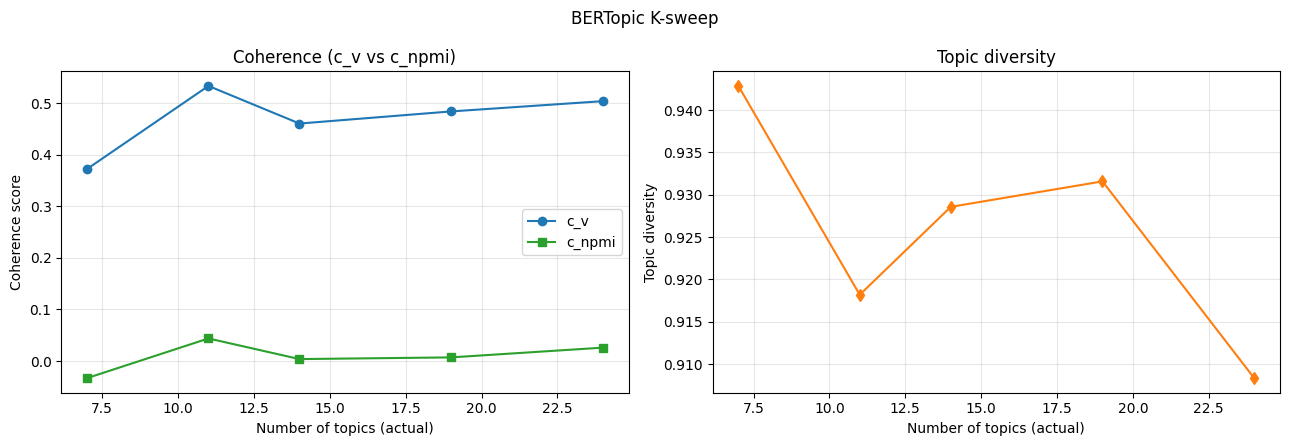


Rekomendasi nr_topics (max combined score): 12
Override manual jika perlu dengan mengubah NUM_TOPICS di cell training di bawah.


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax1 = axes[0]
ax1.plot(sweep_df['K_actual'], sweep_df['c_v'], 'o-', color='tab:blue', label='c_v')
ax1.plot(sweep_df['K_actual'], sweep_df['c_npmi'], 's-', color='tab:green', label='c_npmi')
ax1.set_xlabel('Number of topics (actual)')
ax1.set_ylabel('Coherence score')
ax1.set_title('Coherence (c_v vs c_npmi)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(sweep_df['K_actual'], sweep_df['diversity'], 'd-', color='tab:orange')
ax2.set_xlabel('Number of topics (actual)')
ax2.set_ylabel('Topic diversity')
ax2.set_title('Topic diversity')
ax2.grid(alpha=0.3)

plt.suptitle('BERTopic K-sweep')
fig.tight_layout()
plt.show()

best_idx = sweep_df['combined'].idxmax()
best_k = int(sweep_df.loc[best_idx, 'K_target'])
print(f"\nRekomendasi nr_topics (max combined score): {best_k}")
print("Override manual jika perlu dengan mengubah NUM_TOPICS di cell training di bawah.")

## Final Model

In [19]:
NUM_TOPICS = 25
print(f"Training final BERTopic with nr_topics={NUM_TOPICS}")

np.random.seed(SEED)
torch.manual_seed(SEED)

model = BERTopic(
    embedding_model=embed_model,
    vectorizer_model=shared_vectorizer,
    nr_topics=NUM_TOPICS,
    calculate_probabilities=True,
    verbose=True,
)
topics, probs = model.fit_transform(docs, embeddings=doc_embeddings)

top_words = bertopic_top_words(model, topn=15)
final_metrics = evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10)
print(
    f"\nFinal BERTopic | target K={NUM_TOPICS}  actual={len(top_words)}"
    f"  c_v={final_metrics['c_v']:.4f}"
    f"  c_npmi={final_metrics['c_npmi']:.4f}"
    f"  diversity={final_metrics['diversity']:.4f}\n"
)
for i, tw in enumerate(top_words):
    print(f"Topic {i}: {tw}")

bertopic_metrics = {**final_metrics, 'model': 'BERTopic', 'K': len(top_words)}

2026-06-24 02:47:33,137 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Training final BERTopic with nr_topics=25


2026-06-24 02:48:05,018 - BERTopic - Dimensionality - Completed ✓
2026-06-24 02:48:05,021 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-24 02:49:39,681 - BERTopic - Cluster - Completed ✓
2026-06-24 02:49:39,682 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
2026-06-24 02:49:40,307 - BERTopic - Representation - Completed ✓
2026-06-24 02:49:40,308 - BERTopic - Topic reduction - Reducing number of topics
2026-06-24 02:49:40,370 - BERTopic - Representation - Fine-tuning topics using representation models.
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
2026-06-24 02:49:40,893 - BERTopic - Representation - Completed ✓
2026-06-24 02:49:40,898


Final BERTopic | target K=25  actual=24  c_v=0.4983  c_npmi=0.0166  diversity=0.9125

Topic 0: cursor app build game claude new using one time use
Topic 1: agents build create agent platform decentralized defi needed earn without
Topic 2: llm openai models model codeassist gpt new one build use
Topic 3: chatgpt tools video chat chatbot research writing youtube podcast voice
Topic 4: neural networks deep learning network series reinforcement quantum forecasting lstm
Topic 5: machine learning science books data courses top free artificial read
Topic 6: python programming beginners data kindle link guide science libraries pandas
Topic 7: gensyn network decentralized saas compute gpu company testnet companies power
Topic 8: doctors healthcare medical practice health care practices doctor clinical services
Topic 9: cloud agent blackbox remote terminal aether assign autonomous tasks cli
Topic 10: layoffs jobs india tech indian job laid cuts due engineers
Topic 11: storage walrus decentraliz

In [20]:
new_topics = model.reduce_outliers(docs, topics)

100%|██████████| 22/22 [00:02<00:00,  7.78it/s]


In [21]:
# Topic info table dari built-in BERTopic
topic_info = model.get_topic_info()
topic_info.head(24)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,21110,-1_build_app_new_one,"[build, app, new, one, tools, agents, time, pe...",[ever imagine build defi app without writing s...
1,0,7334,0_cursor_app_build_game,"[cursor, app, build, game, claude, new, using,...",[people use one vibecode agent past week used ...
2,1,2584,1_agents_build_create_agent,"[agents, build, create, agent, platform, decen...",[fractionai lets anyone build train agents usi...
3,2,2233,2_llm_openai_models_model,"[llm, openai, models, model, codeassist, gpt, ...",[best thing llm assisted code give everyone to...
4,3,674,3_chatgpt_tools_video_chat,"[chatgpt, tools, video, chat, chatbot, researc...",[productivity tools chatbots chatgpt claude ge...
5,4,170,4_neural_networks_deep_learning,"[neural, networks, deep, learning, network, se...","[tool training deep neural networks, deep lear..."
6,5,146,5_machine_learning_science_books,"[machine, learning, science, books, data, cour...","[best machine learning data engineers, best ma..."
7,6,142,6_python_programming_beginners_data,"[python, programming, beginners, data, kindle,...","[using python data science, python programming..."
8,7,138,7_gensyn_network_decentralized_saas,"[gensyn, network, decentralized, saas, compute...",[gensyn products powering decentralized comput...
9,8,125,8_doctors_healthcare_medical_practice,"[doctors, healthcare, medical, practice, healt...",[code development advancing fast means healthc...


In [22]:
model.update_topics(docs, topics=new_topics, vectorizer_model=shared_vectorizer)

2026-06-24 02:51:45,218 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


In [23]:
# Topic info table dari built-in BERTopic
topic_info = model.get_topic_info()
topic_info.head(24)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7,-1_gecem_viberecruiting_zapp_powercuts,"[gecem, viberecruiting, zapp, powercuts, ile, ...",[ever imagine build defi app without writing s...
1,0,16715,0_app_build_one_new,"[app, build, one, new, cursor, time, people, c...",[people use one vibecode agent past week used ...
2,1,6160,1_agents_build_create_platform,"[agents, build, create, platform, web, agent, ...",[fractionai lets anyone build train agents usi...
3,2,4740,2_llm_models_model_openai,"[llm, models, model, openai, reasoning, new, u...",[best thing llm assisted code give everyone to...
4,3,2082,3_chatgpt_tools_video_research,"[chatgpt, tools, video, research, writing, con...",[productivity tools chatbots chatgpt claude ge...
5,4,374,4_deep_neural_networks_learning,"[deep, neural, networks, learning, network, se...","[tool training deep neural networks, deep lear..."
6,5,653,5_learning_machine_science_data,"[learning, machine, science, data, books, lear...","[best machine learning data engineers, best ma..."
7,6,447,6_python_programming_data_guide,"[python, programming, data, guide, beginners, ...","[using python data science, python programming..."
8,7,684,7_company_companies_network_saas,"[company, companies, network, saas, ceo, compu...",[gensyn products powering decentralized comput...
9,8,269,8_doctors_healthcare_practice_medical,"[doctors, healthcare, practice, medical, healt...",[code development advancing fast means healthc...


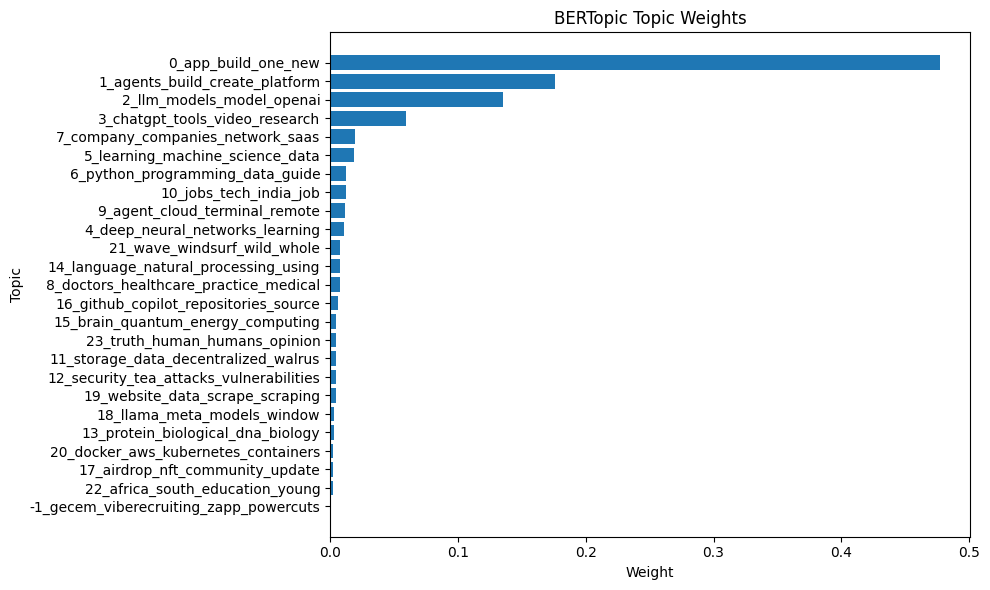

In [24]:
import matplotlib.pyplot as plt

topic_info["Weight"] = (
    topic_info["Count"] / topic_info["Count"].sum()
)

plot_df = topic_info.sort_values("Weight", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Name"], plot_df["Weight"])

plt.xlabel("Weight")
plt.ylabel("Topic")
plt.title("BERTopic Topic Weights")

plt.tight_layout()
plt.show()

In [25]:
# Intertopic distance map
fig = model.visualize_topics()
fig.show()

In [26]:
fig_heatmap = model.visualize_heatmap()
fig_heatmap.show()

In [27]:
# Top words per topic dengan c-TF-IDF weights
fig = model.visualize_barchart(top_n_topics=NUM_TOPICS, n_words=20)
fig.show()

In [28]:
# Hierarchical view
fig = model.visualize_hierarchy()
fig.show()

In [29]:
# Sample tweets per topic untuk inspeksi kualitatif
def sample_docs_for_topic(topic_id, n=3):
    idx = [i for i, t in enumerate(topics) if t == topic_id]
    if not idx:
        return []
    pick = np.random.choice(idx, size=min(n, len(idx)), replace=False)
    return [docs[i] for i in pick]

# Skip outlier topic -1, ambil top 10 berdasarkan size
non_outlier = topic_info[topic_info['Topic'] != -1].head(24)
for _, row in non_outlier.iterrows():
    tid = row['Topic']
    print(f"\n=== Topic {tid} | size={row['Count']} | {row['Name'][:80]} ===")
    for s in sample_docs_for_topic(tid, n=30):
        print(" -", s[:200])


=== Topic 0 | size=16715 | 0_app_build_one_new ===
 - holy cursor raised valuation vibecode might new normal
 - two new vibecode crypto app week something never seen bangers
 - vibecode worked vibecoders would revenue
 - vibecode crazy tell spent last couple hours debugging supabase auth jumping back forth bolt chatgpt clue either saying able direct pinpoint error
 - builder biggest fear accidentally copying someone else work working hard something feel like getting harder things build definitely become commonplace vibecode
 - viberman running cross megaman battle network slay spire awesome able vibecode games wish existed
 - rewriting rules web dev literally vibecode gives anyone confidence code much security experts say introduces new risks fast delivers results crystal scoop
 - vibecode really crashed today trying speed definition import database follow cascading set issues might time rip start
 - vibecode much absolutely hate tomorrow code scratch use old stackoverflow googling th

## Topic over Time

Memvisualisasikan evolusi topik sepanjang waktu memakai kolom `created_at` dari dataset
sumber (`vibe_coding_combined_translated.csv`). File preprocessed tidak menyimpan timestamp,
jadi `created_at` direkonstruksi dengan menjalankan ulang pipeline preprocessing yang **identik**
dengan `preprocess_new.ipynb` (decode HTML -> lowercase -> hapus URL/mention/hashtag ->
normalisasi "vibe coding" -> tokenize -> buang stopword + token <=2 char -> filter dokumen
>= 4 token). Karena pipeline ini deterministik & mempertahankan urutan baris, hasilnya selaras
per-posisi dengan `docs` (BERTopic TIDAK men-shuffle docs, sehingga mapping langsung 1:1).

In [30]:
# Hitung representasi topik per bin waktu. Data span ~13 bulan -> nr_bins=13 (~bulanan).
# BERTopic me-recompute c-TF-IDF per bin memakai topik global yang sudah di-fit.
topics_over_time = model.topics_over_time(docs, timestamps, nr_bins=13)
topics_over_time.head()

12it [00:03,  3.47it/s]


,Topic,Words,Frequency,Timestamp
0,-1,"vibesecuritiesfraud, vibemanaging, viberecruit...",2,2025-01-31 15:14:24
1,0,"cursor, app, build, game, one",2780,2025-01-31 15:14:24
2,1,"agents, build, create, powered, agent",789,2025-01-31 15:14:24
3,2,"llm, models, model, deepseek, openai",774,2025-01-31 15:14:24
4,3,"chatgpt, video, tools, writing, research",314,2025-01-31 15:14:24


In [31]:
# Visualisasi frekuensi topik sepanjang waktu (outlier -1 otomatis di-exclude).
fig = model.visualize_topics_over_time(topics_over_time, top_n_topics=NUM_TOPICS)

# Pindahkan legend ke bawah graph (horizontal) supaya area plot lebih lebar.
fig.update_layout(
    legend=dict(
        orientation="h",      # legend mendatar
        yanchor="top",
        y=-0.20,              # di bawah area plot (negatif = di luar bawah)
        xanchor="center",
        x=0.5,
        title_text="",
    ),
    margin=dict(b=160),       # ruang ekstra di bawah untuk menampung legend
)
fig.show()

In [32]:
#save the model
model.save("bertopic_model")

2026-06-24 03:17:55,656 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
